# 1.2 Autoencoders

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

We will be using

- **Pytorch**. Since pytorch can use GPUs or TPUs if available, it is usually better to force all data types to be `np.float32` or `int`.

- The **MNIST** digits classification dataset. Observe how **we normalize** the MNIST images.

## 1. Load data

In [2]:
mnist = pd.read_csv("local/data/mnist1.5k.csv.gz", compression="gzip", header=None).values
X=(mnist[:,1:785]/255.).astype(np.float32)
y=(mnist[:,0]).astype(int)
print("dimension de las imagenes y las clases", X.shape, y.shape)

dimension de las imagenes y las clases (1500, 784) (1500,)


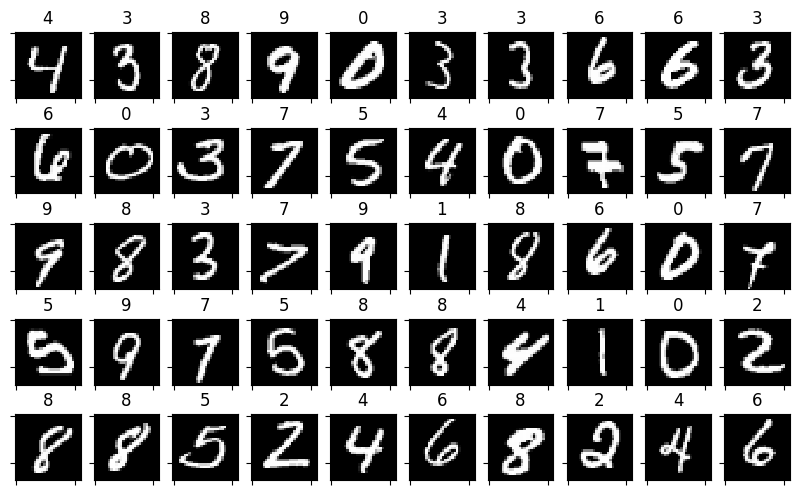

In [3]:
perm = np.random.permutation(list(range(X.shape[0])))[0:50]
random_imgs   = X[perm]
random_labels = y[perm]
fig = plt.figure(figsize=(10,6))
for i in range(random_imgs.shape[0]):
    ax=fig.add_subplot(5,10,i+1)
    plt.imshow(random_imgs[i].reshape(28,28), interpolation="nearest", cmap = plt.cm.Greys_r)
    ax.set_title(int(random_labels[i]))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

and we do the regular train/test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1200, 784), (300, 784), (1200,), (300,))

## 2. Building the data loading pipeline


setup a dataloader from the data arrays. **Observe we need to convert arrays to tensors**

In [22]:
tX_train = torch.from_numpy(X_train)
ty_train = torch.from_numpy(y_train)

tX_test = torch.from_numpy(X_test)
ty_test = torch.from_numpy(y_test)
tX_train, ty_train

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([4, 5, 8,  ..., 0, 1, 9]))

In [24]:
train_dataset = TensorDataset(tX_train, ty_train)
test_dataset = TensorDataset(tX_test, ty_test)

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,      # Good practice for training
    num_workers=0      # Increase if on Linux/Mac for faster loading
)

we can now loop over the data

In [28]:
for x,y in train_loader:
    break

In [29]:
x.shape, y.shape

(torch.Size([32, 784]), torch.Size([32]))

## 3. Assemble and train an autoencoder

Observe how an autoencoder is just a concatenation of two regular `Linear` layers. **Why are we using a sigmoid as decoder output activation?**

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

class Autoencoder(nn.Module):
    def __init__(self, input_size, code_size):
        super().__init__()
        
        self.encoder = nn.Linear(input_size, code_size)
        self.decoder = nn.Linear(code_size, input_size)

    def forward(self, x):
        x = self.encoder(x)
        x = F.relu(x)
        x = self.decoder(x)
        x = F.sigmoid(x)
        return x

# Example instantiation
model = Autoencoder(input_size=X_train.shape[1], code_size=50)
summary(model)

Layer (type:depth-idx)                   Param #
Autoencoder                              --
├─Linear: 1-1                            39,250
├─Linear: 1-2                            39,984
Total params: 79,234
Trainable params: 79,234
Non-trainable params: 0

test we can do inference on the model (still not trained)

In [32]:
o = model(x)
x.shape, o.shape

(torch.Size([32, 784]), torch.Size([32, 784]))

In [35]:
torch.mean((o-x)**2)

tensor(0.2337, grad_fn=<MeanBackward0>)

the training loop.

This is **self supervised** actual digit class `y` is not needed

In [55]:
n_epochs = 20
model = Autoencoder(input_size=X_train.shape[1], code_size=50)
optimizer = optim.Adam(model.parameters(), lr=0.001)

lossh = []
for epoch in range(n_epochs):
        model.train()  # IMPORTANT: Enables Dropout
        running_loss = 0.0

        # discard y
        for batch_idx, (x,_) in enumerate(train_loader):
            # Move data to GPU if available
            #data, target = data.to(device), target.to(device)
            
            # --- The Core Training Steps ---
            # 1. Clear gradients from the previous step
            optimizer.zero_grad()
            
            # 2. Forward pass: compute predicted outputs
            output = model(x)
            
            # 3. Calculate loss
            loss = torch.mean((output-x)**2)
            
            # 4. Backward pass: compute gradient of the loss
            loss.backward()
            
            # 5. Optimization: update weights
            optimizer.step()
            
            running_loss += loss.item()

            lossh.append(loss.detach().numpy())
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {running_loss/len(train_loader):.4f}")

print("Training Complete!")

Epoch 1/20 | Loss: 0.1474
Epoch 2/20 | Loss: 0.0718
Epoch 3/20 | Loss: 0.0643
Epoch 4/20 | Loss: 0.0566
Epoch 5/20 | Loss: 0.0501
Epoch 6/20 | Loss: 0.0459
Epoch 7/20 | Loss: 0.0429
Epoch 8/20 | Loss: 0.0406
Epoch 9/20 | Loss: 0.0388
Epoch 10/20 | Loss: 0.0372
Epoch 11/20 | Loss: 0.0355
Epoch 12/20 | Loss: 0.0341
Epoch 13/20 | Loss: 0.0326
Epoch 14/20 | Loss: 0.0313
Epoch 15/20 | Loss: 0.0300
Epoch 16/20 | Loss: 0.0288
Epoch 17/20 | Loss: 0.0277
Epoch 18/20 | Loss: 0.0267
Epoch 19/20 | Loss: 0.0257
Epoch 20/20 | Loss: 0.0248
Training Complete!


Text(0, 0.5, 'loss')

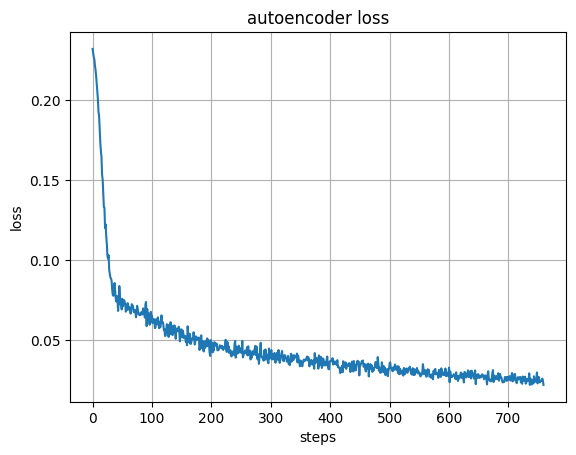

In [58]:
plt.plot(lossh)
plt.grid()
plt.title('autoencoder loss')
plt.xlabel('steps')
plt.ylabel('loss')

The training seems to have gone well (the loss was reduced)

Question: How can we measure how good was the result?

You can try with larger layers, with more layers, etc.

## 4. Making predictions

We can feed the model any input and get the output. Observe we get eager tensors, which are like a symbolic wrapper to numpy matrices. We will see more about this later in this course.

In [62]:
o = model(tX_train)
o

tensor([[1.9636e-04, 3.1769e-05, 3.5965e-05,  ..., 1.9458e-04, 5.7361e-04,
         1.1649e-03],
        [1.2703e-05, 5.4995e-06, 4.3363e-06,  ..., 5.3665e-05, 2.0513e-06,
         9.2996e-06],
        [4.6748e-05, 3.4401e-04, 7.5340e-05,  ..., 5.3532e-05, 3.7670e-04,
         2.2886e-04],
        ...,
        [1.5485e-05, 1.9044e-05, 1.1678e-07,  ..., 2.1331e-06, 3.5517e-06,
         1.1852e-06],
        [9.6858e-05, 5.9470e-05, 1.7524e-04,  ..., 4.8068e-04, 7.6015e-05,
         4.9587e-04],
        [2.5601e-04, 6.3442e-05, 1.4185e-04,  ..., 2.7881e-04, 5.1418e-04,
         4.0303e-04]], grad_fn=<SigmoidBackward0>)

This is an autoencoder, so hopefuly the prediction (the reconstruction) should be similar to the input